# Simple PhysioNet metrics

This notebook contains a simple set of metrics derived from data extracted from the PhysioNet database.

## Setup

In [1]:
import os

import matplotlib.pyplot as plt
import polars as pl

## Load data

Loading data for analysis, including:

- users
- projects
- historical data (pre-2020)

In [2]:
# path to datasets
base_path = os.path.join("..", "data", "physionet")

# iterate folder
for file in os.listdir(base_path):
    print(file)

users.csv
projects.csv


In [3]:
users = pl.read_csv(os.path.join(base_path, "users.csv"))
projects = pl.read_csv(os.path.join(base_path, "projects.csv"))

In [ ]:
users.head()

In [ ]:
projects.head()

## Metrics

Extract simple metrics from the user and project data.

In [5]:
# Convert date columns to date type
users = users.with_columns(pl.col("join_date").str.strptime(pl.Date, "%Y-%m-%d"))
projects = projects.with_columns(pl.col("publish_date").str.to_datetime("%Y-%m-%d %H:%M:%S%.f%z", strict=False))

In [6]:
# Number of new users per year
users_per_year = users.with_columns(
    pl.col("join_date").dt.year().alias("year")
).group_by("year").agg(
    pl.count("user_id").alias("count")
)
users_per_year

year,count
i32,u32
2019,6773
2022,21289
2020,15461
2023,29237
2021,18536
2024,20617


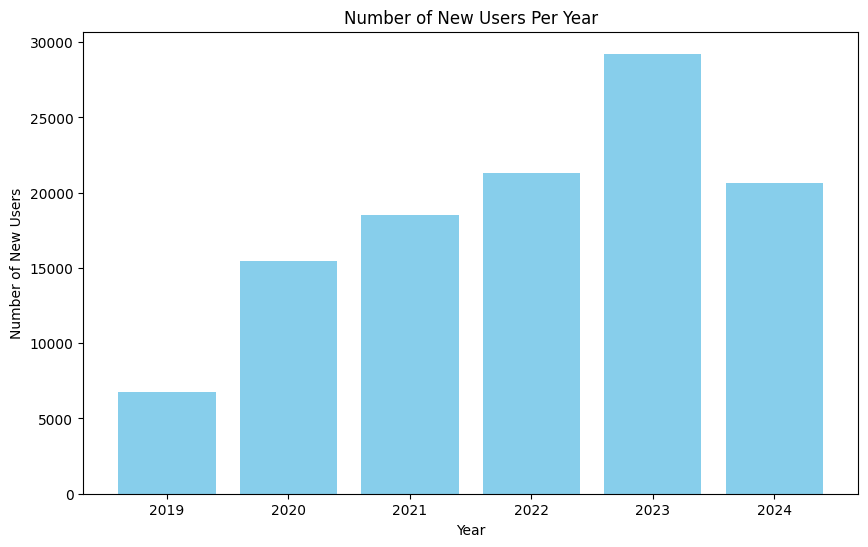

In [7]:
# Plot number of new users per year
plt.figure(figsize=(10, 6))
plt.bar(users_per_year["year"].to_list(), users_per_year["count"].to_list(), color='skyblue')
plt.xlabel("Year")
plt.ylabel("Number of New Users")
plt.title("Number of New Users Per Year")
plt.xticks(users_per_year["year"].to_list())
plt.show()

In [8]:
# Number of new published projects per year
projects_per_year = projects.with_columns(
    pl.col("publish_date").dt.year().alias("year")
).group_by("year").agg(
    pl.count("project_id").alias("count")
)
projects_per_year

year,count
i32,u32
2013,4
2008,8
2015,10
2020,44
2018,18
…,…
2006,2
2016,16
2022,72


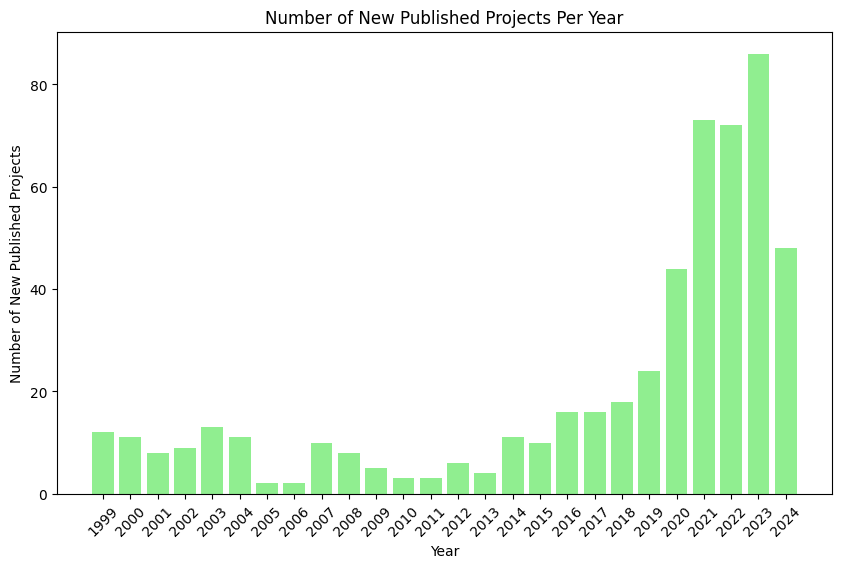

In [9]:
# Plot number of new published projects per year
plt.figure(figsize=(10, 6))
plt.bar(projects_per_year["year"].to_list(), projects_per_year["count"].to_list(), color='lightgreen')
plt.xlabel("Year")
plt.ylabel("Number of New Published Projects")
plt.title("Number of New Published Projects Per Year")
plt.xticks(projects_per_year["year"].to_list(), rotation=45)
plt.show()